Saved figure to: nmse_plot.png


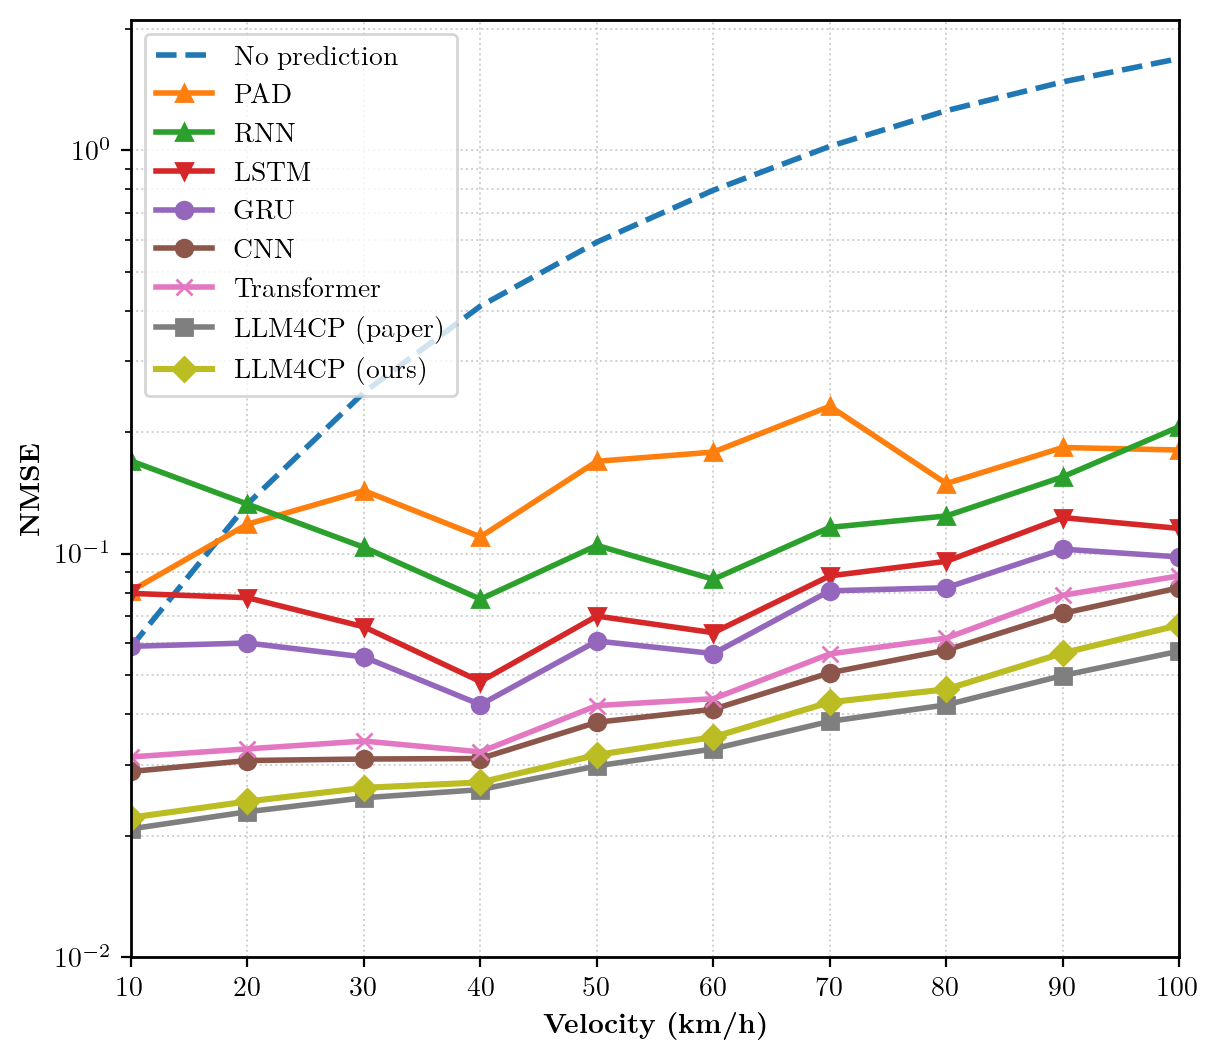

In [ ]:
# plot_nmse_vs_velocity.py
# Usage:
#   python plot_nmse_vs_velocity.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- LaTeX style settings ----------------
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{lmodern}",
    "axes.edgecolor": "black",
    "axes.linewidth": 1,
})

# ---------------- File paths ----------------
# mode, csv_path, out_name = "tdd", "test.csv", "nmse_plot_tdd.png"
mode, csv_path, out_name = "fdd", "test_fdd.csv", "nmse_plot_fdd.png"

# ---------------- Load CSV ----------------
# Each row = one model, 10 comma-separated values (speeds 10..100 km/h)
df = pd.read_csv(csv_path, header=None)
data = df.values.astype(float)  # shape: (n_models, 10)

# x-axis velocities (km/h)
velocities = np.arange(10, 101, 10)

# ---------------- Plot order & styles ----------------
# plot_order = [
#     ("No prediction", 6, dict(linestyle="--", marker=None, linewidth=2.0)),
#     ("PAD",           7, dict(marker="^",  linewidth=2.0)),
#     ("RNN",           5, dict(marker="^",  linewidth=2.0)),   # triangle up
#     ("LSTM",          4, dict(marker="v",  linewidth=2.0)),   # triangle down
#     ("GRU",           3, dict(marker="o",  linewidth=2.0)),
#     ("CNN",           2, dict(marker="o",  linewidth=2.0)),
#     ("Transformer",   1, dict(marker="x",  linewidth=2.0)),
#     ("LLM4CP",        0, dict(marker="s",  linewidth=2.0)),   # square
# ]

if mode == "tdd":
    plot_order = [
        ("No prediction", 7, dict(linestyle="--", marker=None, linewidth=2.0)),
        ("PAD",           8, dict(marker="^",  linewidth=2.0)),
        ("RNN",           6, dict(marker="^",  linewidth=2.0)),   # triangle up
        ("LSTM",          5, dict(marker="v",  linewidth=2.0)),   # triangle down
        ("GRU",           4, dict(marker="o",  linewidth=2.0)),
        ("CNN",           3, dict(marker="o",  linewidth=2.0)),
        ("Transformer",   2, dict(marker="x",  linewidth=2.0)),
        ("LLM4CP (paper)",  1, dict(marker="s",  linewidth=2.0)),   # square
        ("LLM4CP (ours)", 0, dict(marker="D", linewidth=2.2)),  # diamond
    ]
elif mode == "fdd":
    plot_order = [
        ("No prediction", 7, dict(linestyle="--", marker=None, linewidth=2.0)),
        ("RNN",           6, dict(marker="^",  linewidth=2.0)),   # triangle up
        ("LSTM",          5, dict(marker="v",  linewidth=2.0)),   # triangle down
        ("GRU",           4, dict(marker="o",  linewidth=2.0)),
        ("CNN",           3, dict(marker="o",  linewidth=2.0)),
        ("Transformer",   2, dict(marker="x",  linewidth=2.0)),
        ("LLM4CP (paper)",  1, dict(marker="s",  linewidth=2.0)),   # square
        ("LLM4CP (ours)", 0, dict(marker="D", linewidth=2.2)),  # diamond
    ]



# ---------------- Figure ----------------
plt.figure(figsize=(6.2, 5.4), dpi=200)
ax = plt.gca()
ax.set_yscale("log")

for label, row_idx, style in plot_order:
    y = data[row_idx]
    y = np.asarray(y[:len(velocities)], dtype=float)
    plt.plot(velocities, y, label=label, markersize=6, **style)

# ---------------- Labels & axes ----------------
plt.xlabel(r"\textbf{Velocity (km/h)}")
plt.ylabel(r"\textbf{NMSE}")
plt.xlim(10, 100)
plt.ylim(1e-2,)
plt.xticks(velocities)

# Grid + legend
ax.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.6)
plt.legend(loc="upper left", frameon=True)

plt.tight_layout()
plt.savefig(out_name, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {out_name}")
